In [ ]:
# Problem Statement : Install and configure TensorFlow/Keras .
# Perform data preprocessing , normalization , train-test split as well as visualization on sample dataset. 
# Build a simple neural network model using Keras and train it on the preprocessed data. Evaluate the model's performance and visualize the results.



#Import TensorFlow for building and training the neural network and matplotlib for displaying images
import tensorflow as tf
import matplotlib.pyplot as plt 

In [ ]:
#Load the dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [ ]:
#Normalize pixel values from 0-255 to 0-1
train_images = train_images /255.0
test_images  = test_images  /255.0

In [ ]:
# Display the shape of the training and testing datasets
print(train_images.shape)
print(test_images.shape)
print(train_labels)

(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


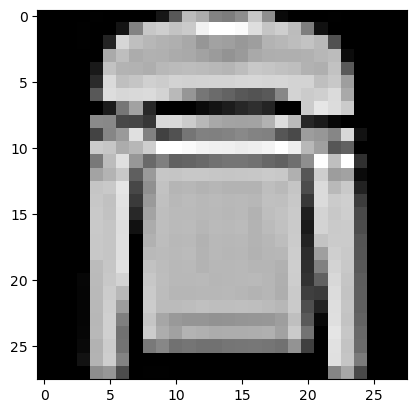

In [ ]:
#Display the 6th image from the training dataset
plt.imshow(train_images[5], cmap='gray')
plt.show()

In [ ]:
# Create a Sequential neural network model
my_model = tf.keras.models.Sequential()

# Flatten the 28x28 image into a single vector of 784 values
my_model.add(tf.keras.layers.Flatten(input_shape=(28,28)))

# Add a hidden layer with 128 neurons and ReLU activation and the output layer with 10 neurons
my_model.add(tf.keras.layers.Dense(128, activation='relu'))
my_model.add(tf.keras.layers.Dense(10, activation='softmax'))



# Compile the model using the Adam optimizer
my_model.compile(optimizer='adam' , loss='sparse_categorical_crossentropy' , metrics=['accuracy'])


# Train the model using the training images and labels
my_model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8242 - loss: 0.4995
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8651 - loss: 0.3763
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8770 - loss: 0.3374


In [ ]:
# Evaluate the trained model using the test dataset
val_loss, val_acc = my_model.evaluate(test_images, test_labels)
print('Test accuracy : ', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8581 - loss: 0.3941
Test accuracy :  0.8580999970436096


In [ ]:
# Save the trained model
my_model.save('model.keras')